In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Upload the CSV file manually in Colab
from google.colab import files
uploaded = files.upload()

# Load the dataset
df = pd.read_csv("sales_clean.csv")

# Display first 5 rows
df.head()

Saving sales_clean.csv to sales_clean.csv


,Datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,2014-02-01,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,2014-03-01,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,2014-04-01,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,2014-05-01,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,2014-06-01,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [2]:
# Shape of the dataset
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types and non-null counts
df.info()

Shape: (2106, 13)

Columns:
['Datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06', 'Year', 'Month', 'Hour', 'Weekday Name']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Datum         2106 non-null   object 
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   object 
dtypes: float64(8), int64(3), object(2)
memory usage: 214.0+ KB


In [5]:
# Convert datum to datetime format
df["Datum"] = pd.to_datetime(df["Datum"])

# Confirm conversion
df["Datum"].head()

,Datum
0,2014-02-01
1,2014-03-01
2,2014-04-01
3,2014-05-01
4,2014-06-01


In [7]:
# List of drug category columns
drug_cols = [
    "M01AB", "M01AE", "N02BA", "N02BE",
    "N05B", "N05C", "R03", "R06"
]

# Create total_sales column
df["total_sales"] = df[drug_cols].sum(axis=1)

# Preview results
df[["Datum", "total_sales"]].head()

,Datum,total_sales
0,2014-02-01,48.47
1,2014-03-01,107.00
2,2014-04-01,91.35
3,2014-05-01,66.10
4,2014-06-01,58.20


In [8]:
df["total_sales"].describe()

,total_sales
count,2106.000000
mean,60.586659
std,21.561684
min,0.000000
25%,46.446750
50%,58.466500
75%,72.814250
max,198.950000


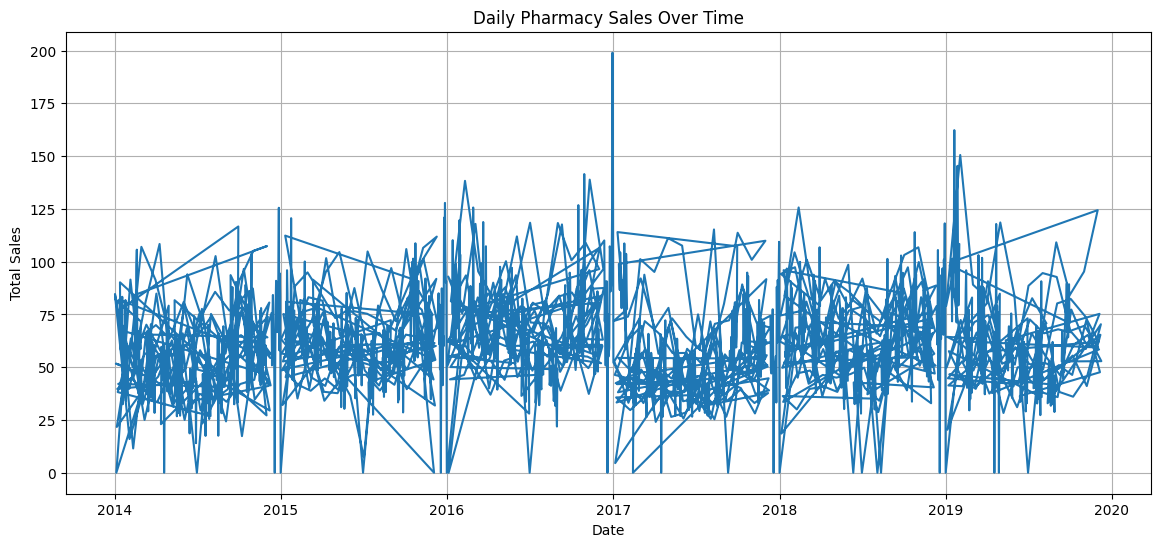

In [9]:
plt.figure(figsize=(14,6))
plt.plot(df["Datum"], df["total_sales"])
plt.title("Daily Pharmacy Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

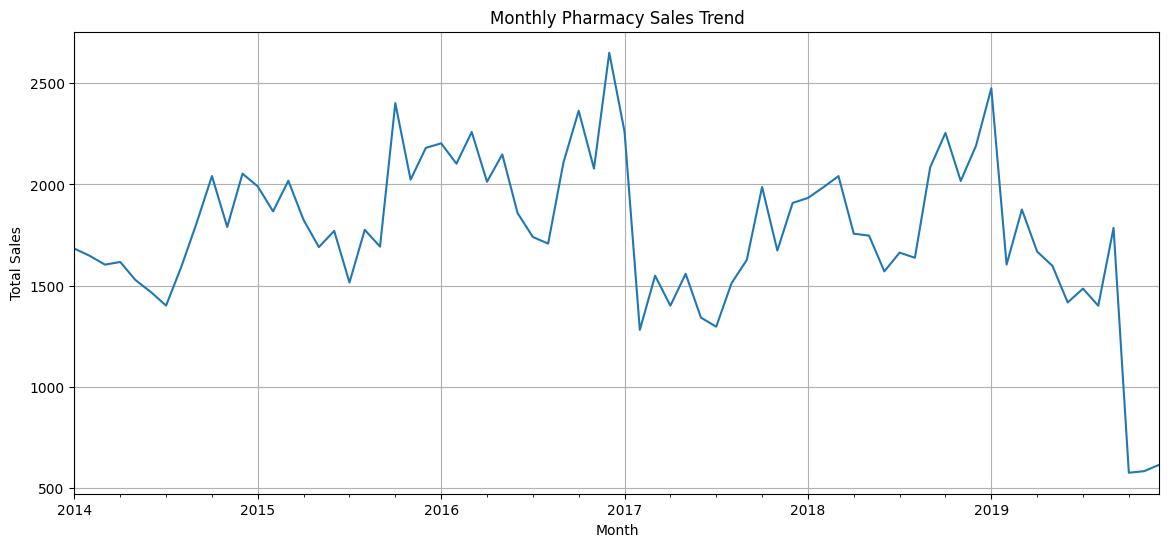

In [11]:
# Create year-month period
df["year_month"] = df["Datum"].dt.to_period("M")

# Aggregate monthly sales
monthly_sales = (
    df.groupby("year_month")["total_sales"]
      .sum()
)

# Plot monthly sales
plt.figure(figsize=(14, 6))
monthly_sales.plot()
plt.title("Monthly Pharmacy Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

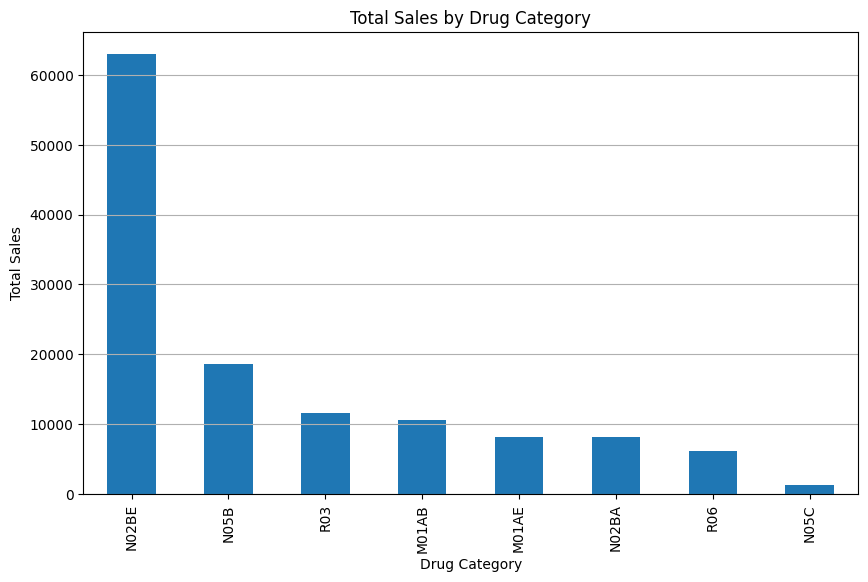

In [12]:
# Total sales by drug category
category_totals = df[drug_cols].sum().sort_values(ascending=False)

# Plot bar chart
plt.figure(figsize=(10, 6))
category_totals.plot(kind="bar")
plt.title("Total Sales by Drug Category")
plt.xlabel("Drug Category")
plt.ylabel("Total Sales")
plt.grid(axis="y")
plt.show()

In [13]:
# Correlation matrix for drug categories
correlation = df[drug_cols + ["total_sales"]].corr()

# Display the correlation matrix
correlation.round(2)

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,total_sales
M01AB,1.00,0.19,0.15,0.18,0.03,0.02,0.08,0.09,0.34
M01AE,0.19,1.00,0.17,0.29,0.06,0.03,0.09,0.03,0.40
N02BA,0.15,0.17,1.00,0.21,0.18,0.06,0.04,-0.03,0.36
N02BE,0.18,0.29,0.21,1.00,0.07,0.00,0.22,-0.13,0.87
N05B,0.03,0.06,0.18,0.07,1.00,0.25,0.04,-0.06,0.36
N05C,0.02,0.03,0.06,0.00,0.25,1.00,0.01,-0.00,0.13
R03,0.08,0.09,0.04,0.22,0.04,0.01,1.00,0.01,0.49
R06,0.09,0.03,-0.03,-0.13,-0.06,-0.00,0.01,1.00,0.02
total_sales,0.34,0.40,0.36,0.87,0.36,0.13,0.49,0.02,1.00
